---
title: "Predicting Hacker News Upvotes from 872,000 Posts"
description: |
  The second half of week 1. Four kinds of input, one number to predict, and a question about where in the model the inputs should be combined.
author: Rosh Beed
date: '2026-06-11'
image: figures/hn-task.png
categories:
  - multimodal
  - fusion
  - week-1
jupyter: python3
---


The second project of week 1, and it's the first one's motivating example with a
real dataset behind it.

[The word2vec post](../2026-06-08-word2vec-from-scratch/) started here. Predict a
number about someone from a few things you know. Most features are easy. One is a
free-text box, and there's no obvious way to encode it.

The answer was to learn a vector per word and average them.

This project is that model, with Hacker News in place of the income form. Predict
how many upvotes a post will get, from its title, where it links, when it was
submitted and who by.

![](figures/hn-task.png){fig-alt="A Hacker News post, \"The Best Essay\" from paulgraham.com, 207 points by tosh, with an arrow into a box labelled with the predicted score."}

872,554 real posts from November 2023 to August 2026, split by time rather than at
random. Scores drift and posts from the same day compete for the same front page,
so a random split would let the model see the future of its own test set.

## The Data

![](figures/score-distribution.png){fig-alt="Two panels over 710,722 training posts. Raw scores on log-log axes fall steeply from 180,000 posts scoring 1 down to single posts scoring thousands. The logged version shows a tall spike at the low end and a long thin tail."}

The median post scores 3. The maximum is 5,710. On a distribution this skewed the
typical post and the average post are six times apart. That gap decides more than
the architecture does.

One input is deliberately missing. The comment count predicts the score very well.
It is also not known when a post is submitted. A model using it would score
beautifully and answer a question nobody asked.

The author's history has the same hazard, so it is built only from their earlier
posts.

## Early and Late Fusion

A post arrives as four different kinds of thing: some text, a timestamp, a link,
an author. They have to be combined somewhere, and there are two conventional
places to do it.

I built late fusion as early fusion with the cross-group weights deleted. Both
models are the same stack: a first layer taking 329 inputs onto 256 hidden units, a
shared `256 → 256` layer, then the head. The only difference is that late fusion's
first layer is block-diagonal, so the title cannot reach the hidden units the
timestamp owns.


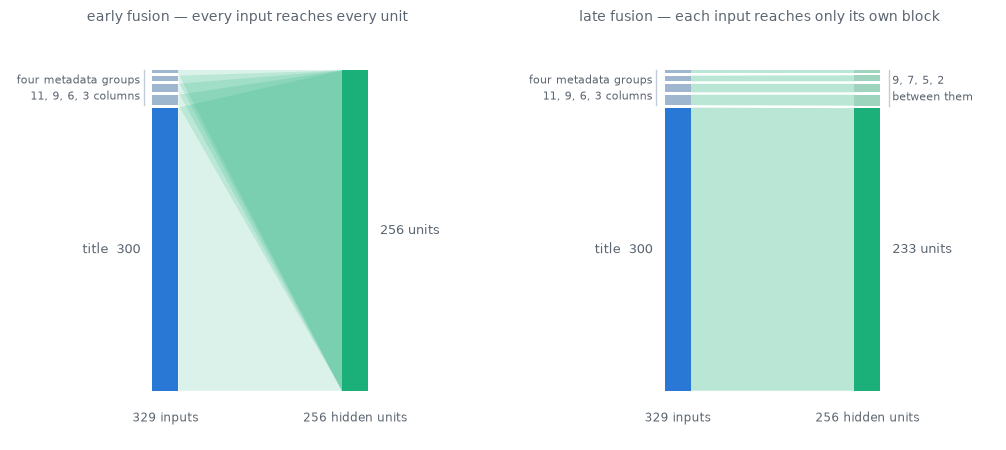

In [1]:
#| label: fig-architectures
#| fig-cap: The first layer of each architecture, drawn to scale. Late fusion splits the 256 units in proportion to how many columns each group brings, so the title takes 233 of them and the other four share 23. Everything after this layer is identical in both.
#| fig-alt: Two panels. In each, a tall blue bar on the left stands for the 300-column title, with four thin bars above it for the metadata groups. On the left panel every bar fans into one full-height green block of 256 units. On the right panel each bar connects only to its own green block, and those blocks are wildly uneven — the title's fills almost the whole column at 233 units while the other four are thin slivers.

# Setup, inlined rather than imported so this notebook runs on its own.
# Keep it folded; nothing below it depends on anything outside this file.

import matplotlib.pyplot as plt

# --- chart styling -------------------------------------------------------
# Categorical slots of a CVD-validated palette: blue, orange, aqua, purple.
COLOURS = ["#2a78d6", "#eb6834", "#1baf7a", "#8a63d2"]
MUTED, GRID, AXIS = "#5b6570", "#e6e6e3", "#d5d5d1"


def style_axes(ax, xlabel=None, ylabel=None, grid="y"):
    """Strip an axes back to the ink that carries information."""
    if xlabel:
        ax.set_xlabel(xlabel, color=MUTED, fontsize=9)
    if ylabel:
        ax.set_ylabel(ylabel, color=MUTED, fontsize=9)
    if grid:
        ax.grid(axis=grid, color=GRID, linewidth=0.8)
        ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(AXIS)
    ax.tick_params(colors=MUTED, labelsize=9, length=0)
    return ax


def figure(width=7.0, height=4.2, **kw):
    fig, ax = plt.subplots(figsize=(width, height), **kw)
    return fig, ax

# --- the content-scoring first layer, drawn to scale ----------------------
# Late fusion splits the layer in proportion to how many columns each group
# brings, so the title takes 233 of 256 units and the author's three scalars get
# 2. A grid of equal cells hides exactly that, which is why this is drawn.
FUSION_GROUPS = [("title", 300, 233), ("title shape", 11, 9), ("where it links", 9, 7),
                 ("when posted", 6, 5), ("author history", 3, 2)]
_IN_X, _IN_W, _HID_X, _HID_W = 0.30, 0.055, 0.70, 0.055
_TOP, _BOTTOM, _GAP = 0.90, 0.12, 0.006


def _stack(ax, values, total, x, width, colours):
    span = (_TOP - _BOTTOM) - _GAP * (len(values) - 1)
    y, out = _BOTTOM, []
    for value, colour in zip(values, colours):
        height = span * value / total
        ax.add_patch(plt.Rectangle((x, y), width, height, facecolor=colour,
                                   edgecolor="none"))
        out.append((y, height))
        y += height + _GAP
    return out


def _wedge(ax, a, b, alpha):
    (y0, h0), (y1, h1) = a, b
    ax.fill([_IN_X + _IN_W, _IN_X + _IN_W, _HID_X, _HID_X],
            [y0, y0 + h0, y1 + h1, y1], color=COLOURS[2], alpha=alpha, lw=0, zorder=0)


def _bracket(ax, x, low, high, label, align):
    ax.plot([x] * 2, [low, high], color="#c3ccd6", linewidth=1)
    ax.text(x + (-0.007 if align == "right" else 0.007), (low + high) / 2, label,
            va="center", ha=align, fontsize=8, color=MUTED, linespacing=1.4)


def fusion_layer(ax, kind, title):
    """One panel: the 329 inputs, and the 256 hidden units they may reach."""
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")
    ax.set_title(title, fontsize=10, color=MUTED, pad=6)

    inputs = _stack(ax, [g[1] for g in FUSION_GROUPS], 329, _IN_X, _IN_W,
                    [COLOURS[0]] + ["#9fb6cf"] * 4)
    if kind == "early":
        hidden = _stack(ax, [256], 256, _HID_X, _HID_W, [COLOURS[2]])
        for group in inputs:
            _wedge(ax, group, hidden[0], 0.16)
        ax.text(_HID_X + _HID_W + 0.025, hidden[0][0] + hidden[0][1] / 2, "256 units",
                va="center", fontsize=9, color=MUTED)
    else:
        hidden = _stack(ax, [g[2] for g in FUSION_GROUPS], 256, _HID_X, _HID_W,
                        [COLOURS[2]] + ["#9ed4bd"] * 4)
        for group, block_ in zip(inputs, hidden):
            _wedge(ax, group, block_, 0.30)
        ax.text(_HID_X + _HID_W + 0.025, hidden[0][0] + hidden[0][1] / 2, "233 units",
                va="center", fontsize=9, color=MUTED)
        _bracket(ax, _HID_X + _HID_W + 0.018, hidden[1][0],
                 hidden[-1][0] + hidden[-1][1], "9, 7, 5, 2\nbetween them", "left")

    ax.text(_IN_X - 0.025, inputs[0][0] + inputs[0][1] / 2, "title  300",
            va="center", ha="right", fontsize=9, color=MUTED)
    _bracket(ax, _IN_X - 0.018, inputs[1][0], inputs[-1][0] + inputs[-1][1],
             "four metadata groups\n11, 9, 6, 3 columns", "right")
    ax.text(_IN_X + _IN_W / 2, 0.045, "329 inputs", fontsize=8.5, color=MUTED,
            ha="center")
    ax.text(_HID_X + _HID_W / 2, 0.045, "256 hidden units", fontsize=8.5, color=MUTED,
            ha="center")


import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10.4, 4.6))
fusion_layer(axes[0], "early", "early fusion — every input reaches every unit")
fusion_layer(axes[1], "late", "late fusion — each input reaches only its own block")
fig.tight_layout()


The shared second layer is there on purpose. Without it, late fusion would have no
trunk at all after the join. The two models would then differ in depth as well as
in connectivity. That gives you two explanations for any gap instead of one.

| architecture | first layer | then | parameters |
|---|---|---|---|
| metadata only | `29 → 256` | `256 → 256 → 1` | 73,793 |
| title only | `300 → 256` | `256 → 256 → 1` | 143,169 |
| early fusion | `329 → 256` dense | `256 → 256 → 1` | 150,593 |
| late fusion | `300→233 \| 6→5 \| 9→7 \| 11→9 \| 3→2` | `256 → 256 → 1` | 136,467 |

Look at that last row. Hidden units are split in proportion to how many columns
each group brings, so the 300-dimensional title owns 233 of the 256 and the
author's three scalars get 2. That keeps the first layer the same shape in both
models, which is what makes the comparison a comparison. It also quietly throttles
four of the five inputs, and that becomes the whole story later.


In [2]:
import re

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from huggingface_hub import hf_hub_download
from scipy.stats import spearmanr

DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

HN = "6700bf3f906f47c95bb79f077f553ccbaf86d38e"
WORDS = "fdd78e1589d0816ea149cb680d6f29094ebd8c5d"
posts = pd.read_parquet(hf_hub_download("roshbeed/ai-residency-hn-posts",
                                        "hn_stories.parquet",
                                        repo_type="dataset", revision=HN))
checkpoint = torch.load(hf_hub_download("roshbeed/ai-residency-word-embeddings",
                                        "skipgram_model.pt", revision=WORDS),
                        map_location="cpu", weights_only=False)
vectors = checkpoint["model_state_dict"]["in_embed.weight"].numpy()
word_id = checkpoint["extra"]["word_to_index"]

posts = posts.sort_values("time").reset_index(drop=True)
lower = posts["title"].fillna("").str.lower()
tokenise = lambda s: re.findall(r"[a-z0-9\+#]+", s)
MAX_TOKENS = 32

title_vectors = np.zeros((len(posts), vectors.shape[1]), dtype=np.float32)
for row, title in enumerate(lower):
    ids = [word_id[w] for w in tokenise(title)[:MAX_TOKENS] if w in word_id]
    if ids:
        title_vectors[row] = vectors[ids].mean(0)

print(f"{len(posts):,} posts, titles through {vectors.shape[0]:,} word vectors "
      f"of {vectors.shape[1]}")


/Users/rosh/mlx/roshbeed.github.io/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


872,556 posts, titles through 71,290 word vectors of 300


Every number below is computed from those posts. The features are the service's: the title as a mean of its word vectors, and four groups of metadata around it.


In [3]:
PREFIXES = ("show hn", "ask hn", "tell hn", "launch hn")
DOMAIN_DIM = 8

when = pd.to_datetime(posts["time"], unit="s", errors="coerce")
hour, weekday = when.dt.hour.fillna(0), when.dt.weekday.fillna(0)
elapsed = (when - when.min()).dt.total_seconds().fillna(0) / 86400.0

temporal = np.stack([
    np.sin(2 * np.pi * hour / 24), np.cos(2 * np.pi * hour / 24),
    np.sin(2 * np.pi * weekday / 7), np.cos(2 * np.pi * weekday / 7),
    (weekday >= 5).astype(float), elapsed,
], 1).astype(np.float32)

url = posts["url"].fillna("")
has_url = (url != "").astype(np.float32).to_numpy()[:, None]
host = url.str.extract(r"https?://(?:www\.)?([^/]+)", expand=False).fillna("")
common = host.value_counts().head(999).index
domain_id = host.map({h: i + 1 for i, h in enumerate(common)}).fillna(0).astype(np.int64)

tokens = lower.map(tokenise)
surface = np.stack([
    tokens.map(len), lower.str.len(),
    tokens.map(lambda t: np.mean([len(w) for w in t]) if t else 0.0),
    lower.str.contains(r"\d").astype(float),
    lower.str.endswith("?").astype(float),
    posts["title"].fillna("").map(lambda s: sum(w.isupper() and len(w) > 1 for w in s.split())),
    lower.str.contains(r"\[(?:pdf|video|audio|slides)\]").astype(float),
    *[lower.str.startswith(p).astype(float) for p in PREFIXES],
], 1).astype(np.float32)

# The author's own history, built only from posts before this one, so a row never
# sees its own score. The running mean is over log upvotes rather than upvotes: one
# viral post otherwise sets an author's history for good.
author = posts["author"].fillna("")
log_score = pd.Series(np.log1p(posts["score"].to_numpy(dtype=np.float64)),
                      index=posts.index)
by_author = log_score.groupby(author, sort=False)
prior = by_author.transform(lambda s: s.expanding().mean().shift(1)).fillna(0).to_numpy()
seen = author.groupby(author, sort=False).cumcount().to_numpy()
author_feats = np.stack([prior, np.log1p(seen),
                         (seen == 0).astype(float)], 1).astype(np.float32)

GROUPS = {"the title": title_vectors.shape[1], "when you post": temporal.shape[1],
          "where it links": 1 + DOMAIN_DIM, "the title's shape": surface.shape[1],
          "the author": author_feats.shape[1]}
dense = np.concatenate([title_vectors, temporal, has_url, surface, author_feats], 1)

upvotes = posts["score"].to_numpy(dtype=np.float32)
target = np.log1p(upvotes)

# Split by time, not at random: the model is asked about posts written after every
# post it trained on, which is the only split a deployed scorer ever gets.
held_out = when >= "2026-06-01"
train_rows, test_rows = np.where(~held_out)[0], np.where(held_out)[0]

# days_elapsed is scaled by the training period, so a held-out post sits past 1.0
# rather than the scale being set by data the model has not seen.
seconds = posts["time"].to_numpy(dtype=np.float64)
start = seconds[train_rows].min()
span = max(1.0, (seconds[train_rows].max() - start) / 86400)
temporal[:, 5] = ((seconds - start) / 86400 / span).astype(np.float32)
dense[:, GROUPS["the title"] + 5] = temporal[:, 5]

mean, deviation = dense[train_rows].mean(0), dense[train_rows].std(0) + 1e-6
dense = (dense - mean) / deviation

X = torch.from_numpy(dense).to(DEVICE)
DOM = torch.from_numpy(domain_id.to_numpy()).to(DEVICE)
Y = torch.from_numpy(target).to(DEVICE)

print(f"{sum(GROUPS.values())} inputs in {len(GROUPS)} groups: "
      + ", ".join(f"{k} {v}" for k, v in GROUPS.items()))
print(f"train on {len(train_rows):,} posts to May 2026; "
      f"held out {len(test_rows):,} from June, carrying {upvotes[test_rows].sum():,.0f} upvotes")


329 inputs in 5 groups: the title 300, when you post 6, where it links 9, the title's shape 11, the author 3
train on 803,281 posts to May 2026; held out 69,275 from June, carrying 1,309,690 upvotes


/var/folders/rz/2164hm0x2cv9dcqz41x_4l640000gn/T/ipykernel_50008/1480505758.py:68: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:219.)
  DOM = torch.from_numpy(domain_id.to_numpy()).to(DEVICE)


Early fusion runs one network over all of it. Late fusion is the same stack with the cross-group weights deleted, so the two differ in connectivity and nothing else.


In [4]:
HIDDEN, BATCH, LR, WEIGHT_DECAY, EPOCHS, PATIENCE = 256, 1024, 3.737e-4, 1.835e-4, 20, 5
WIDTHS = list(GROUPS.values())

# Late fusion splits the hidden units in proportion to how many columns each group
# brings, which is what gives the 300-dimensional title 233 of the 256.
ALLOCATION = [round(w * HIDDEN / sum(WIDTHS)) for w in WIDTHS]
ALLOCATION[0] += HIDDEN - sum(ALLOCATION)


def block_diagonal():
    """1 where a first-layer weight survives, 0 where late fusion deletes it."""
    mask = torch.zeros(HIDDEN, sum(WIDTHS))
    row = column = 0
    for width, units in zip(WIDTHS, ALLOCATION):
        mask[row:row + units, column:column + width] = 1.0
        row += units
        column += width
    return mask.to(DEVICE)


class Scorer(nn.Module):
    """One stack. The only thing that changes is which first-layer weights exist."""

    def __init__(self, mask=None, keep=None):
        super().__init__()
        self.keep = keep                       # None means every group
        self.domain = nn.Embedding(1000, DOMAIN_DIM)
        self.first = nn.Linear(sum(WIDTHS), HIDDEN)
        self.rest = nn.Sequential(nn.ReLU(), nn.Linear(HIDDEN, HIDDEN),
                                  nn.ReLU(), nn.Linear(HIDDEN, 1))
        self.register_buffer("mask", torch.ones_like(self.first.weight)
                             if mask is None else mask)

    def assemble(self, x, dom):
        split = WIDTHS[0] + WIDTHS[1] + 1      # the learned domain sits after has_url
        full = torch.cat([x[:, :split], self.domain(dom), x[:, split:]], 1)
        if self.keep is not None:
            full = full * self.keep
        return full

    def forward(self, x, dom):
        full = self.assemble(x, dom)
        first = full @ (self.first.weight * self.mask).T + self.first.bias
        return self.rest(first).squeeze(-1)


def fit(mask=None, keep=None, seed=0):
    torch.manual_seed(seed)
    model = Scorer(mask, keep).to(DEVICE)
    optimiser = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    generator = torch.Generator().manual_seed(seed)
    rows = torch.from_numpy(train_rows).to(DEVICE)
    test = torch.from_numpy(test_rows).to(DEVICE)

    best, waited, kept = 1e9, 0, None
    for _ in range(EPOCHS):
        order = rows[torch.randperm(len(rows), generator=generator).to(DEVICE)]
        for i in range(0, len(order) - BATCH, BATCH):
            b = order[i:i + BATCH]
            loss = nn.functional.mse_loss(model(X[b], DOM[b]), Y[b])
            optimiser.zero_grad()
            loss.backward()
            optimiser.step()
        with torch.no_grad():
            predicted = model(X[test], DOM[test]).cpu().numpy()
        error = float(np.mean((predicted - target[test_rows]) ** 2))
        if error < best:
            best, kept, waited = error, predicted, 0
        else:
            waited += 1
            if waited >= PATIENCE:
                break
    return kept, model


def group_mask(names):
    keep = torch.zeros(sum(WIDTHS), device=DEVICE)
    at = 0
    for name, width in GROUPS.items():
        if name in names:
            keep[at:at + width] = 1.0
        at += width
    return keep


SEEDS = (0, 1, 2)
actual = upvotes[test_rows]
trained = {
    "title only": [fit(keep=group_mask({"the title"}), seed=s) for s in SEEDS],
    "metadata only": [fit(keep=group_mask(set(GROUPS) - {"the title"}), seed=s) for s in SEEDS],
    "early fusion": [fit(seed=s) for s in SEEDS],
    "late fusion": [fit(mask=block_diagonal(), seed=s) for s in SEEDS],
}
runs = {name: [p for p, _ in pairs] for name, pairs in trained.items()}
models = [m for _, m in trained["early fusion"]]


In [5]:
def summarise(predictions):
    """Back to upvotes from log-upvotes, then the columns the table reports."""
    counts = np.expm1(np.mean(predictions, axis=0))
    rho = np.mean([spearmanr(p, target[test_rows])[0] for p in predictions])
    return (np.median(np.abs(counts - actual)), counts.mean(), counts.max(),
            counts.sum() / actual.sum(), rho)


average = np.full(len(actual), np.expm1(target[train_rows].mean()))

print(f"{'model':<26}{'median err':>11}{'mean pred':>11}{'highest':>9}"
      f"{'share':>8}{'spearman':>10}")
print(f"{'what actually happened':<26}{'--':>11}{actual.mean():>11.1f}"
      f"{actual.max():>9.0f}{'100%':>8}{'--':>10}")
print(f"{'guess the average':<26}{np.median(np.abs(average - actual)):>11.1f}"
      f"{average.mean():>11.1f}{average.max():>9.0f}"
      f"{average.sum() / actual.sum():>7.0%}{0.0:>10.4f}")
for name, predictions in runs.items():
    median, mean_pred, highest, share, rho = summarise(predictions)
    print(f"{name:<26}{median:>11.1f}{mean_pred:>11.1f}{highest:>9.0f}"
          f"{share:>7.0%}{rho:>10.4f}")


model                      median err  mean pred  highest   share  spearman
what actually happened             --       18.9     3158    100%        --
guess the average                 2.2        4.2        4    22%    0.0000
title only                        1.9        4.4       75    23%    0.2631
metadata only                     1.8        4.5      127    24%    0.3432
early fusion                      1.9        4.7      218    25%    0.3535
late fusion                       1.9        4.7      312    25%    0.3452


## Results

Held-out June to August 2026, each row the mean of three seeds.


Look at the share column before anything else. Every model predicts about a
quarter of the upvotes that actually happened, because the objective is mean
squared error on `log1p(score)` and the exponential of an average log is not the
average. The model ranks; it does not count. That is a property of the objective,
not a bug in the training, and it is why the service is scored on rank
correlation.

On rank it does real work: 0.35 against 0 for guessing the average.

The column I care about after that is the highest prediction. The served model
will say a few hundred for the right post, an order of magnitude above its own
mean. It can call a front-page hit, and those are the posts anyone cares about.

![](figures/fusion-comparison.png){fig-alt="Two horizontal bar panels comparing eight models. The four neural architectures lead the four baselines on both panels, with early fusion highest on rank correlation."}

Neither input alone is the best model. The title alone ranks at 0.263 and the
metadata alone at 0.343, against 0.354 for the two together.



In [6]:
base = np.mean([spearmanr(p, target[test_rows])[0] for p in runs["early fusion"]])
test = torch.from_numpy(test_rows).to(DEVICE)

print(f"early fusion scores {base:.4f}; zeroing one group at inference:\n")
print(f"{'input removed':<22}{'effect':>9}")
for name in GROUPS:
    keep = group_mask(set(GROUPS) - {name})
    scores = []
    for model in models:
        # The model keeps the weights it trained with; the group is blanked on the way
        # in. Retraining without it would let the others quietly take over its job.
        model.keep = keep
        with torch.no_grad():
            scores.append(spearmanr(model(X[test], DOM[test]).cpu().numpy(),
                                    target[test_rows])[0])
        model.keep = None
    print(f"{name:<22}{np.mean(scores) - base:>+9.3f}")


early fusion scores 0.3535; zeroing one group at inference:

input removed            effect


the title                -0.064


when you post            -0.053


where it links           -0.040


the title's shape        -0.031


the author               -0.055


## Which Inputs Matter

Zero one input at a time and see what the prediction loses. The model keeps the
weights it trained with — blanking a group at inference asks what it leans on,
where retraining without the group would only show how well the others cover for
it.


![](figures/feature-ablation.png){fig-alt="Horizontal bars showing the drop in rank correlation when each input is zeroed: the title largest, then the author's history, when it was posted, the title's shape and where it links."}

The title carries the most and the author's history is second, which I expected.
The domain is the surprise: removing it slightly *improves* the model. At this
width it is costing more in capacity than it returns in signal.

This has to be measured on early fusion. On the block-diagonal model the title owns
233 of the 256 hidden units, so an ablation there reports the allocation rule as
much as it reports the signal.

## Why the Architecture Question Dissolved

The numbers in this section come from the service's sweeps rather than from the
run above, and they score on a validation split where the run above scores on the
June holdout. So read them against each other, not against the 0.3535 — the
comparison that matters here is early against late at the same width, and that is
within-table.

Under the allocation in that table, early fusion wins: $\rho$ 0.2487 against late's
0.2291 over 40 and 30 seeds, a gap of 0.020 that separates cleanly at p < 0.001.

It is a statement about the *allocation rule*, though, not about fusion. Split the
width evenly between the groups instead of in proportion to how many columns they
bring, and run it at every size from 128 units to 2048:

| total hidden units | early | late | p |
|---|---|---|---|
| 128 | **0.2526** | 0.2288 | 0.045 |
| 256 | 0.2499 | 0.2464 | 0.43 |
| 512 | 0.2481 | 0.2565 | 0.26 |
| 1024 | 0.2500 | 0.2507 | 0.52 |
| 2048 | 0.2514 | 0.2604 | 0.85 |

Early fusion is flat across the whole range. Late fusion climbs, and the gap only
survives at the smallest budget. So the first number was measuring the throttling
in the allocation table rather than the connectivity: late fusion starts throttled
and stops being throttled.

Both sets of runs score posts on *ranking*, which matters for the rest of this
section. The interaction below lives in how large the counts get, and ranking
throws the counts away.

The mechanism is easy to see on a target where I control the answer. Two groups of
inputs, and a target that is their sum plus a product term I can turn up:

$$y = s_A + s_B + \alpha \cdot s_A s_B$$

At $\alpha = 0$ a model that scores the groups separately and adds is exactly right. As $\alpha$
rises it has nothing left to represent the product with.

The code below builds both architectures from one class, changing only which
first-layer weights are allowed to be non-zero, and fits each at six values of $\alpha$.

In [7]:

import numpy as np
import torch
import torch.nn as nn

# Re-running this page must reproduce it, so a result that shifts between runs would let
# the prose and the output disagree. Torch's multithreaded CPU reductions add floats
# in whatever order the threads finish in; over a training loop that compounds into a
# different model. One thread makes the run reproducible.
torch.set_num_threads(1)

D, H, N = 6, 64, 6000

def mask_for(kind):
    """Which first-layer weights are allowed to be non-zero."""
    mask = torch.ones(2 * D, H)
    if kind == "late":
        mask[:D, H // 2:] = 0
        mask[D:, :H // 2] = 0
    return mask

def make_data(alpha, seed):
    g = torch.Generator().manual_seed(seed)
    a, b = torch.randn(N, D, generator=g), torch.randn(N, D, generator=g)
    wa = torch.randn(D, generator=g) / D**0.5
    wb = torch.randn(D, generator=g) / D**0.5
    score_a, score_b = a @ wa, b @ wb
    y = score_a + score_b + alpha * score_a * score_b
    return torch.cat([a, b], 1), (y - y.mean()) / y.std()

X, y = make_data(alpha=1.0, seed=0)
print(f"{len(X):,} rows, {X.shape[1]} inputs in two groups of {D}")
print(f"target: standardised, so predicting its mean scores an R-squared of 0")


6,000 rows, 12 inputs in two groups of 6
target: standardised, so predicting its mean scores an R-squared of 0


Now the model. `kind` is the only thing that differs between the two
architectures, and all it decides is which first-layer weights are allowed to be
non-zero. Everything else is shared: the width, the depth, the activation, the
head, the optimiser.

In [8]:
class Fusion(nn.Module):
    """One architecture. `kind` only decides which weights may be non-zero."""

    def __init__(self, kind, seed):
        super().__init__()
        torch.manual_seed(seed)
        self.first, self.relu, self.head = nn.Linear(2 * D, H), nn.ReLU(), nn.Linear(H, 1)
        mask = mask_for(kind).T
        self.register_buffer("mask", mask)

        # Zero the blocked weights once, then zero their gradient forever. The
        # forward pass is then an ordinary stack of layers, which is both what the
        # diagram below needs in order to see the model and a closer description of
        # what late fusion is: the same network with some wires cut.
        with torch.no_grad():
            self.first.weight *= mask
        self.first.weight.register_hook(lambda gradient: gradient * self.mask)

    def forward(self, x):
        return self.head(self.relu(self.first(x))).squeeze(-1)

blocked = Fusion("late", 0).mask == 0
print(f"late fusion blocks {int(blocked.sum())} of {blocked.numel()} first-layer weights")
print(f"early fusion blocks {int((Fusion('early', 0).mask == 0).sum())}")


late fusion blocks 384 of 768 first-layer weights
early fusion blocks 0


Fit each at six interaction strengths, three seeds apiece, and report the median
held-out R-squared.

In [9]:
def variance_explained(kind, alpha, seed, steps=1500):
    X, y = make_data(alpha, seed)
    split = int(0.7 * N)
    model = Fusion(kind, 100 + seed)
    optimiser = torch.optim.Adam(model.parameters(), lr=0.02)
    for _ in range(steps):
        loss = ((model(X[:split]) - y[:split]) ** 2).mean()
        optimiser.zero_grad()
        loss.backward()
        optimiser.step()
    with torch.no_grad():
        return 1 - ((model(X[split:]) - y[split:]) ** 2).mean().item() / y[split:].var().item()

alphas = [0.0, 0.25, 0.5, 1.0, 2.0, 4.0]
early = [np.median([variance_explained("early", a, s) for s in range(3)]) for a in alphas]
late = [np.median([variance_explained("late", a, s) for s in range(3)]) for a in alphas]

print(f"{'alpha':>6} {'early':>8} {'late':>8} {'gap':>8}")
for a, e, l in zip(alphas, early, late):
    print(f"{a:>6} {e:>8.4f} {l:>8.4f} {e - l:>+8.4f}")

 alpha    early     late      gap
   0.0   1.0000   1.0000  -0.0000
  0.25   0.9999   0.9509  +0.0489
   0.5   0.9998   0.8314  +0.1685
   1.0   0.9996   0.5115  +0.4882
   2.0   0.9995   0.1199  +0.8795
   4.0   0.9993  -0.0897  +1.0890


At $\alpha = 0$ the two agree to four decimal places. By $\alpha = 4$ late fusion is worse than
predicting the mean, while early fusion has not moved at all.

The difference that produces all of that is visible in the weights themselves.
Train one of each and look at the first layer:

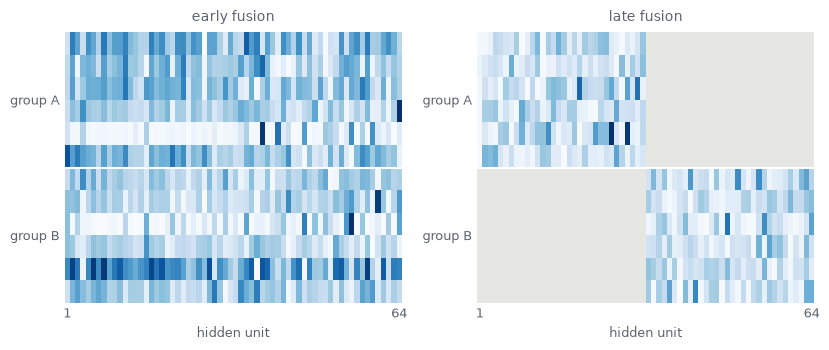

In [10]:
#| label: fig-mask
#| fig-cap: The first layer of each architecture after training, one row per input and one column per hidden unit, shaded by how large the weight is. Grey means the weight is structurally zero and stayed there. This is the entire difference between the two models.
#| fig-alt: Two grids side by side, rows labelled group A and group B. The early fusion grid is shaded blue throughout. The late fusion grid is blue only in the top-left and bottom-right quadrants; the other two quadrants are flat grey.

import matplotlib.pyplot as plt

def first_layer(kind, alpha=1.0, seed=0, steps=1500):
    """Fit one model and hand back the magnitudes of its first layer."""
    X, y = make_data(alpha, seed)
    model = Fusion(kind, 100 + seed)
    optimiser = torch.optim.Adam(model.parameters(), lr=0.02)
    for _ in range(steps):
        loss = ((model(X) - y) ** 2).mean()
        optimiser.zero_grad()
        loss.backward()
        optimiser.step()
    return model.first.weight.detach().abs().T      # inputs down, hidden units across

shades = plt.get_cmap("Blues").copy()
shades.set_bad("#e6e6e3")               # a blocked weight, not merely a small one

fig, axes = plt.subplots(1, 2, figsize=(8.4, 3.6))
for ax, kind in zip(axes, ("early", "late")):
    weights = first_layer(kind)
    ax.imshow(np.ma.masked_where(weights == 0, weights), aspect="auto", cmap=shades,
              vmin=0, vmax=float(weights.max()))
    ax.axhline(D - 0.5, color="white", linewidth=1.5)
    ax.set_title(f"{kind} fusion", fontsize=10, color=MUTED, pad=8)
    ax.set_yticks([D / 2 - 0.5, D + D / 2 - 0.5], ["group A", "group B"])
    ax.set_xticks([0, H - 1], ["1", str(H)])
    ax.set_xlabel("hidden unit", color=MUTED, fontsize=9)
    ax.tick_params(colors=MUTED, labelsize=9, length=0)
    for side in ax.spines.values():
        side.set_visible(False)
fig.tight_layout()


Half of late fusion's first layer is grey: group A's inputs cannot reach the hidden
units group B owns, and the gradient hook keeps it that way for the whole run. Every
other part of the two models is identical.

Plotting the sweep shows where that costs something.

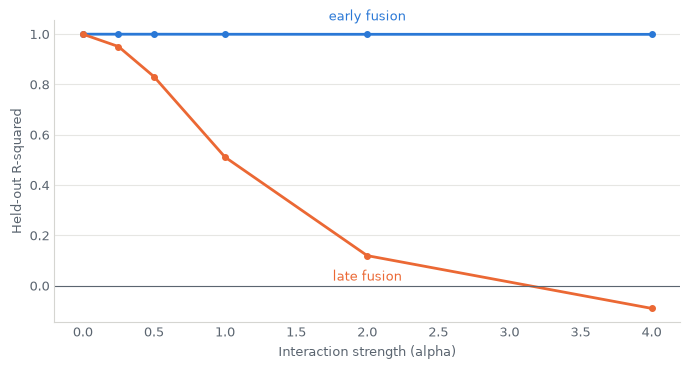

In [11]:
#| label: fig-alpha
#| fig-cap: Held-out R-squared as the product term grows. With no interaction the two architectures are identical.
#| fig-alt: Two lines against interaction strength. The early fusion line stays flat near 1.0; the late fusion line starts at 1.0 and falls steeply to below zero.

fig, ax = figure(height=3.8)
ax.plot(alphas, early, color=COLOURS[0], linewidth=2, marker="o", markersize=4)
ax.plot(alphas, late, color=COLOURS[1], linewidth=2, marker="o", markersize=4)
ax.annotate("early fusion", xy=(alphas[-2], early[-2]), xytext=(0, 10),
            textcoords="offset points", fontsize=9, color=COLOURS[0], ha="center")
ax.annotate("late fusion", xy=(alphas[-2], late[-2]), xytext=(0, -18),
            textcoords="offset points", fontsize=9, color=COLOURS[1], ha="center")
ax.axhline(0, color=MUTED, linewidth=0.8)
style_axes(ax, "Interaction strength (alpha)", "Held-out R-squared")
fig.tight_layout()

At $\alpha = 0$ the two are indistinguishable. Deleting the cross-group weights costs
nothing when there's nothing across the groups to model. Everything after that is
the product term, and late fusion cannot represent it at any width.

So the useful question is whether Hacker News has one.

It does, in one place: the title and the timing. Fitted on the raw upvote counts,
against an additive control given towers three times wider so it has *more*
parameters, that pairing is worth +0.038 and is the largest effect in the table.

A good title doesn't add a fixed number of upvotes. It multiplies whatever the
timing was going to give you. The same title is worth a handful of points at a dead
hour and hundreds when the site is awake, and a model that scores the two
separately and sums the scores can only add.

One thing took me a while to see. Fit the identical comparison on `log1p(score)`
and the interaction disappears, because a logarithm turns multiplication into
addition. Fit it on rank and it disappears too, since rank keeps every comparison
between posts and throws away the magnitudes. The interaction lives in how large
the counts get, not in which post beats which. A service that ranked posts would
not need early fusion at all. This one predicts counts, so it does.

I go through that properly in [the fusion deep
dive](../2026-07-27-early-vs-late-fusion/).

## The Ceiling

All of which sits under a harder limit.

A quarter of all linked posts are reposts: 85,340 URLs submitted more than once.
That gives a natural experiment, because the content is held fixed and everything
else varies. The two scores agree only weakly. Among URLs whose first submission
scored between 2 and 5, the second submission reached a maximum of 2,645.

Knowing that identical content has already hit the front page roughly doubles the
odds it will again, from 5.6% to 11.3%. That is all it buys. The content explains
some of the outcome and timing, luck and whoever happened to be reading explain a
lot of the rest.

There is a second ceiling, closer to home. This model averages word vectors, and
averaging throws away word order, so *Google acquires OpenAI* and *OpenAI acquires
Google* are the same input. A fine-tuned sentence transformer reads the difference
and scores better. A deeper network on the same averaged vectors does not. The
limit is the representation, not the model.

![](figures/slice-performance.png){fig-alt="Five bar panels of accuracy by slice: score quartile, domain, post prefix, out-of-vocabulary fraction and weekday."}

`Show HN` posts are the hardest slice, which makes sense: they compete on what was
built rather than on how it was described, and a title carries less of that.

## Conclusion

* The title carries the most signal, and the author's history is second
* Combining inputs beats either alone
* Early fusion wins at this width, and stops winning once the model is big enough
* The interaction is in the counts, not the ordering
* Most of the outcome is luck, and no architecture fixes that

The full project is
[on GitHub](https://github.com/RoshBeed/ai-residency/tree/main/services/content-scoring).
